In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
d = pd.read_csv('EngineFaultDB_Final.csv')

In [3]:
d.head(2)

,Fault,MAP,TPS,Force,Power,RPM,Consumption L/H,Consumption L/100KM,Speed,CO,HC,CO2,O2,Lambda,AFR
0,0,3.549,1.889,7.428,5.227,1192.769,3.057,11.720,24.901,0.460,196.089,14.356,1.080,1.047,15.385
1,0,3.559,1.899,7.646,5.327,1145.191,2.914,11.276,25.030,0.478,196.283,14.492,1.107,1.083,15.926


In [4]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55999 entries, 0 to 55998
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Fault                55999 non-null  int64  
 1   MAP                  55999 non-null  float64
 2   TPS                  55999 non-null  float64
 3   Force                55999 non-null  float64
 4   Power                55999 non-null  float64
 5   RPM                  55999 non-null  float64
 6   Consumption L/H      55999 non-null  float64
 7   Consumption L/100KM  55999 non-null  float64
 8   Speed                55999 non-null  float64
 9   CO                   55999 non-null  float64
 10  HC                   55999 non-null  float64
 11  CO2                  55999 non-null  float64
 12  O2                   55999 non-null  float64
 13  Lambda               55999 non-null  float64
 14  AFR                  55999 non-null  float64
dtypes: float64(14), int64(1)
memory usag

In [5]:
d.shape

(55999, 15)

In [6]:
d.isna().sum()

Fault                  0
MAP                    0
TPS                    0
Force                  0
Power                  0
RPM                    0
Consumption L/H        0
Consumption L/100KM    0
Speed                  0
CO                     0
HC                     0
CO2                    0
O2                     0
Lambda                 0
AFR                    0
dtype: int64

In [7]:
d.duplicated().sum()

np.int64(1)

In [8]:
d.drop_duplicates(inplace=True)

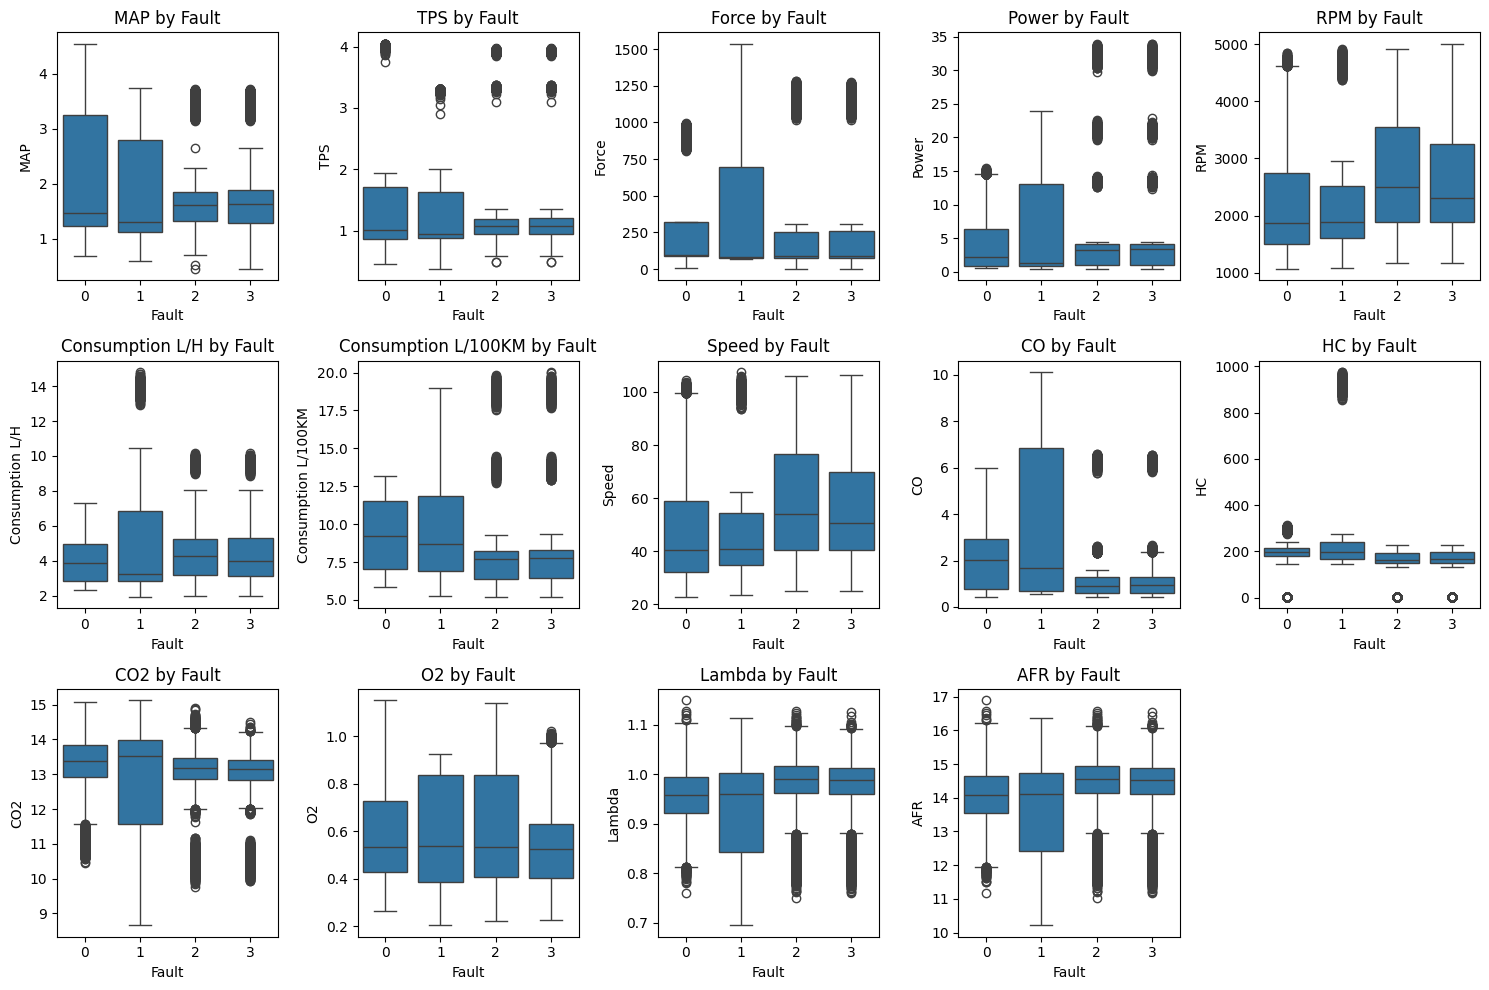

In [9]:
# Fault 유형 별 분포 확인
features = ['MAP', 'TPS', 'Force', 'Power', 'RPM', 'Consumption L/H', 'Consumption L/100KM',
            'Speed', 'CO', 'HC', 'CO2', 'O2', 'Lambda', 'AFR']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(3, 5, i)
    sns.boxplot(x='Fault', y=feature, data=d)
    plt.title(f"{feature} by Fault")
    plt.tight_layout()

<Axes: >

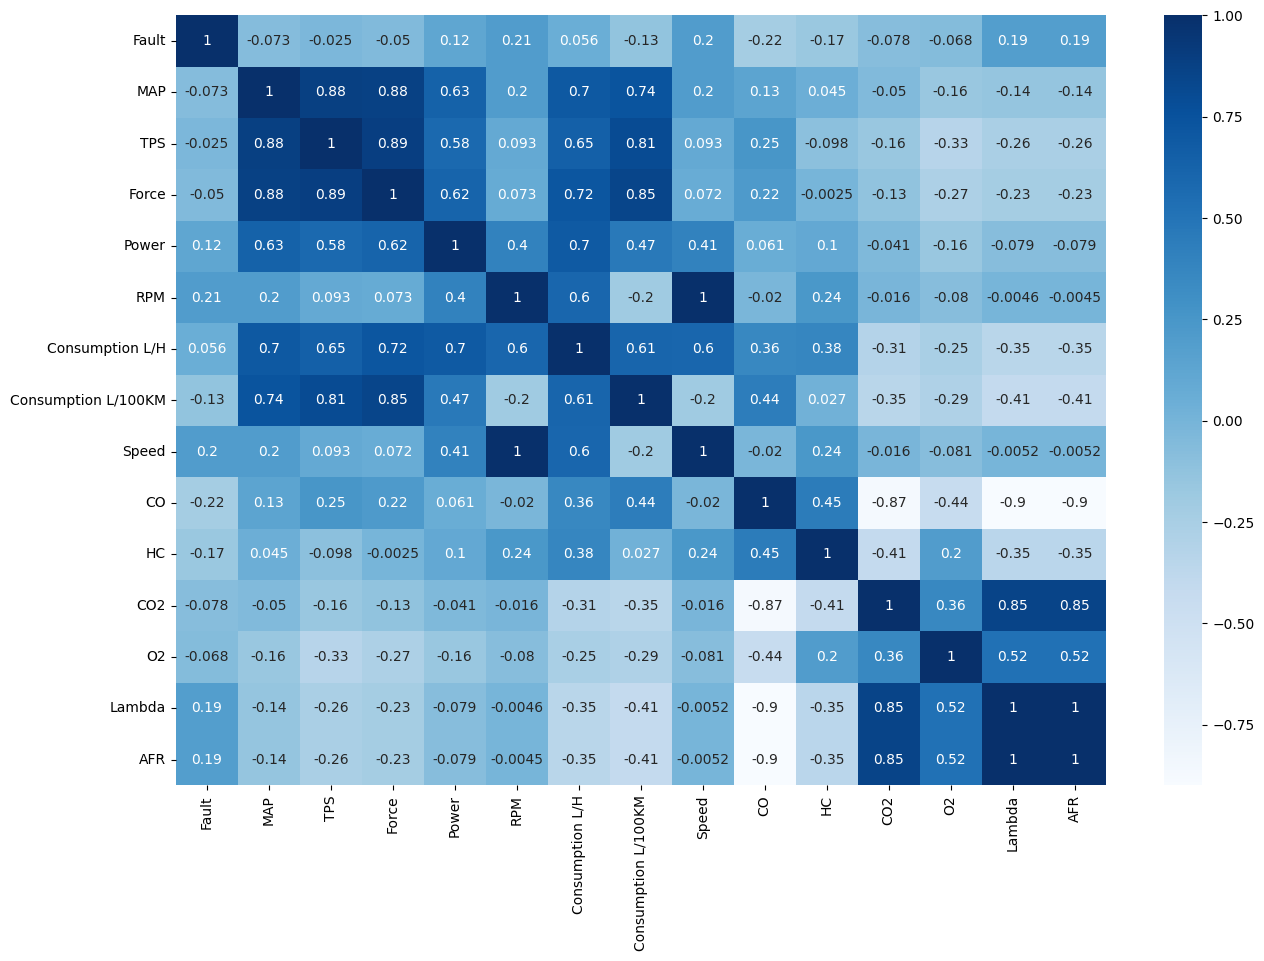

In [10]:
d_corr = d.corr()
plt.figure(figsize=(15,10))
sns.heatmap(d_corr,annot=True,cmap='Blues')

In [11]:
d_0 = d[d['Fault']==0].reset_index(drop=True)
d_1 = d[d['Fault']==1].reset_index(drop=True)
d_2 = d[d['Fault']==2].reset_index(drop=True)
d_3 = d[d['Fault']==3].reset_index(drop=True)

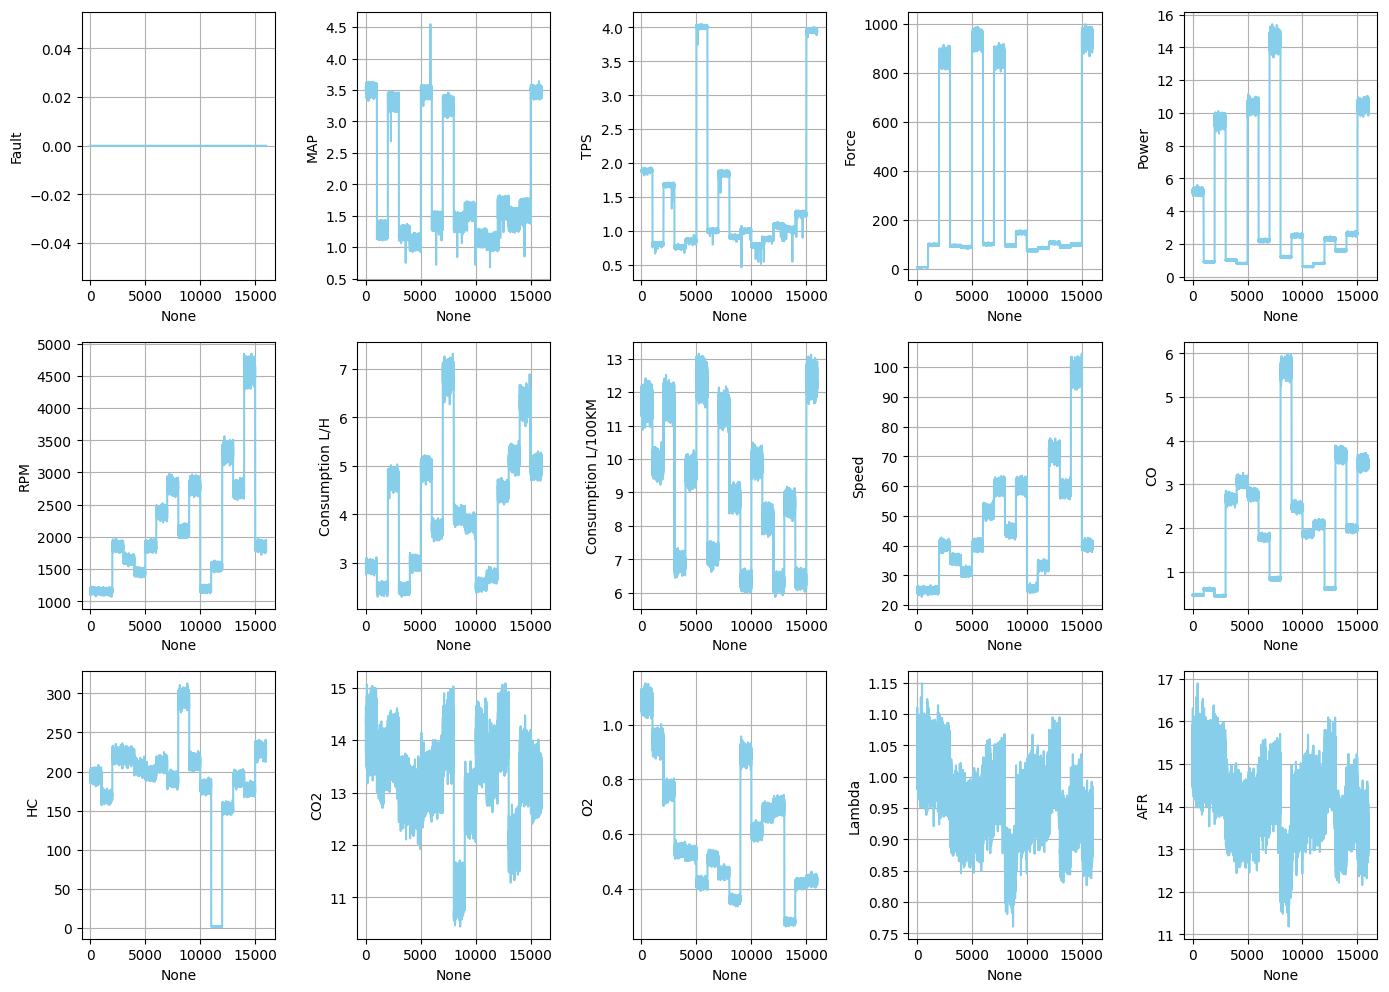

In [12]:
c_0 = d_0.columns

plt.figure(figsize=(14,10))
for i,col in enumerate(c_0):
  plt.subplot(3,5,i+1)
  sns.lineplot(x=d_0.index,y=col,data=d_0,color='skyblue')
  plt.grid()

plt.tight_layout()
plt.show()

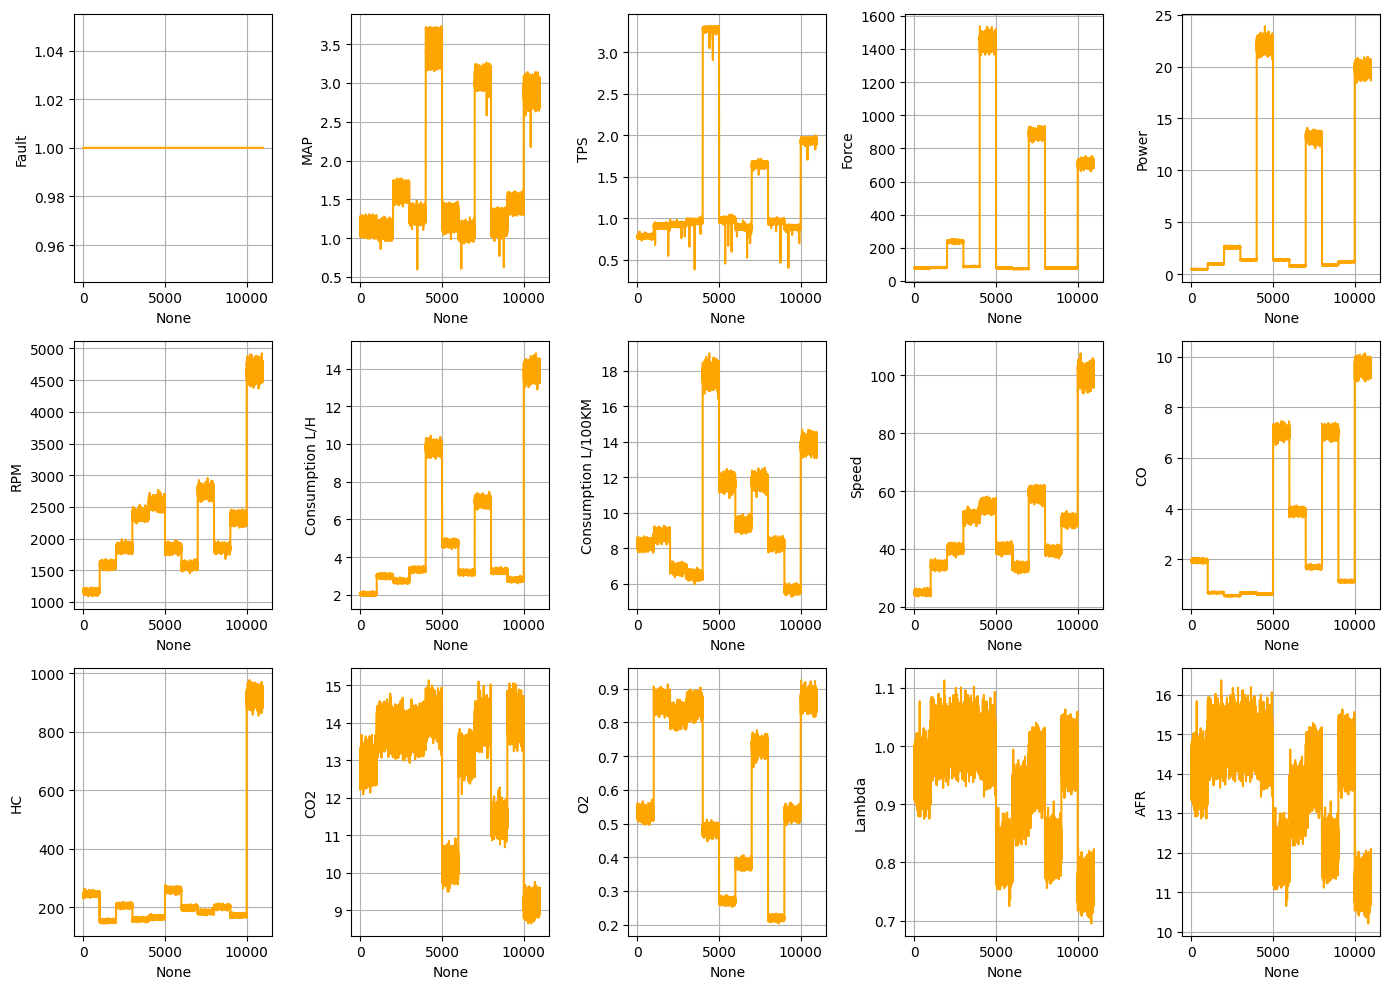

In [13]:
c_1 = d_1.columns

plt.figure(figsize=(14,10))
for i,col in enumerate(c_1):
  plt.subplot(3,5,i+1)
  sns.lineplot(x=d_1.index,y=col,data=d_1,color='orange')
  plt.grid()

plt.tight_layout()
plt.show()

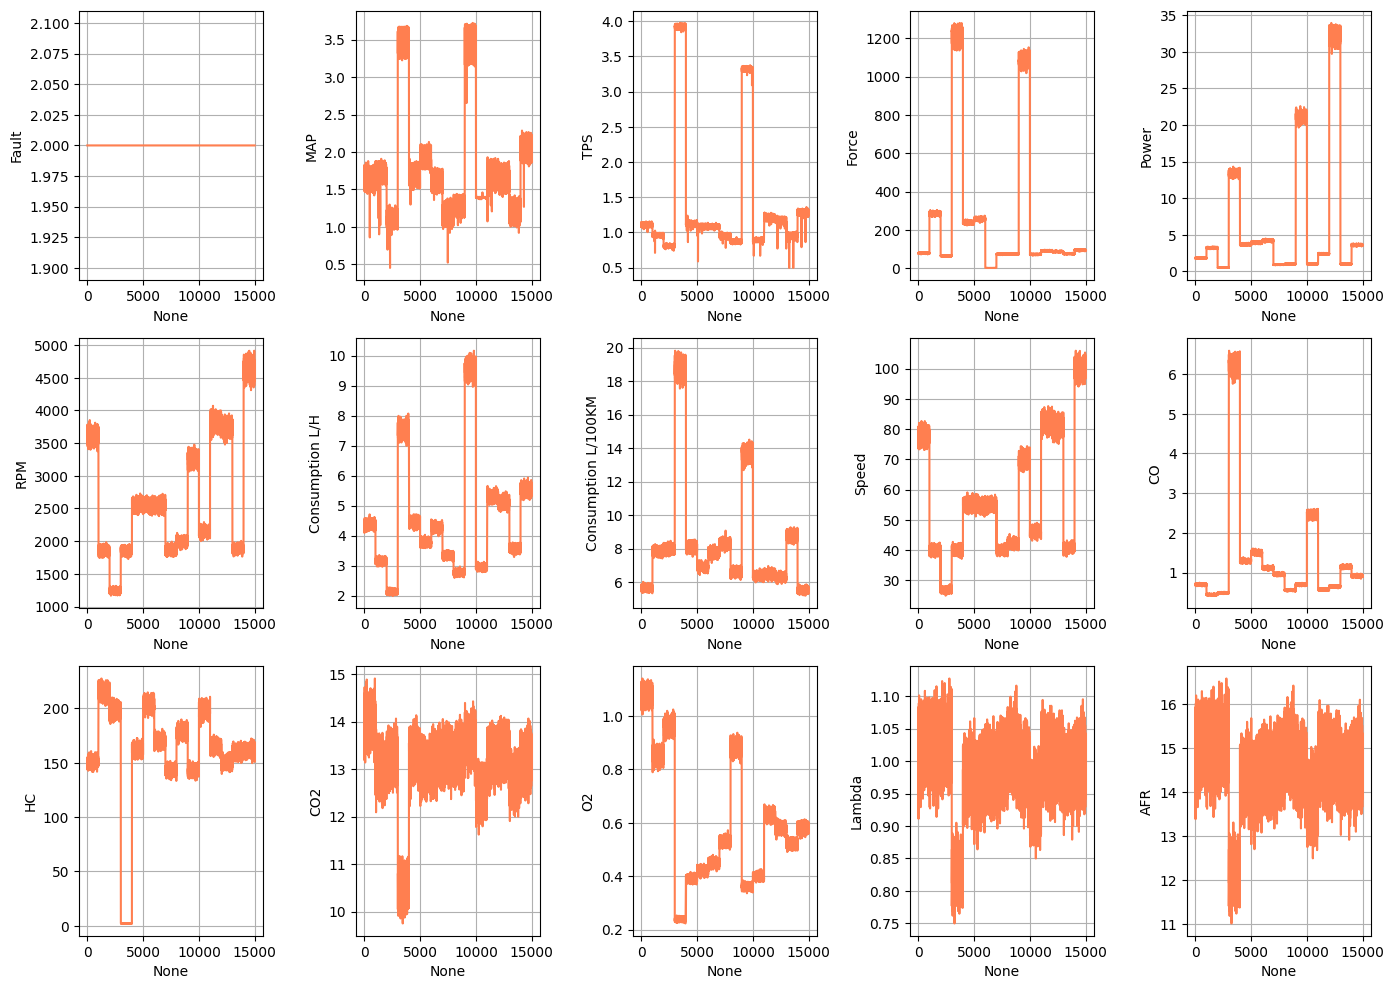

In [14]:
c_2 = d_2.columns

plt.figure(figsize=(14,10))
for i,col in enumerate(c_2):
  plt.subplot(3,5,i+1)
  sns.lineplot(x=d_2.index,y=col,data=d_2,color='coral')
  plt.grid()

plt.tight_layout()
plt.show()

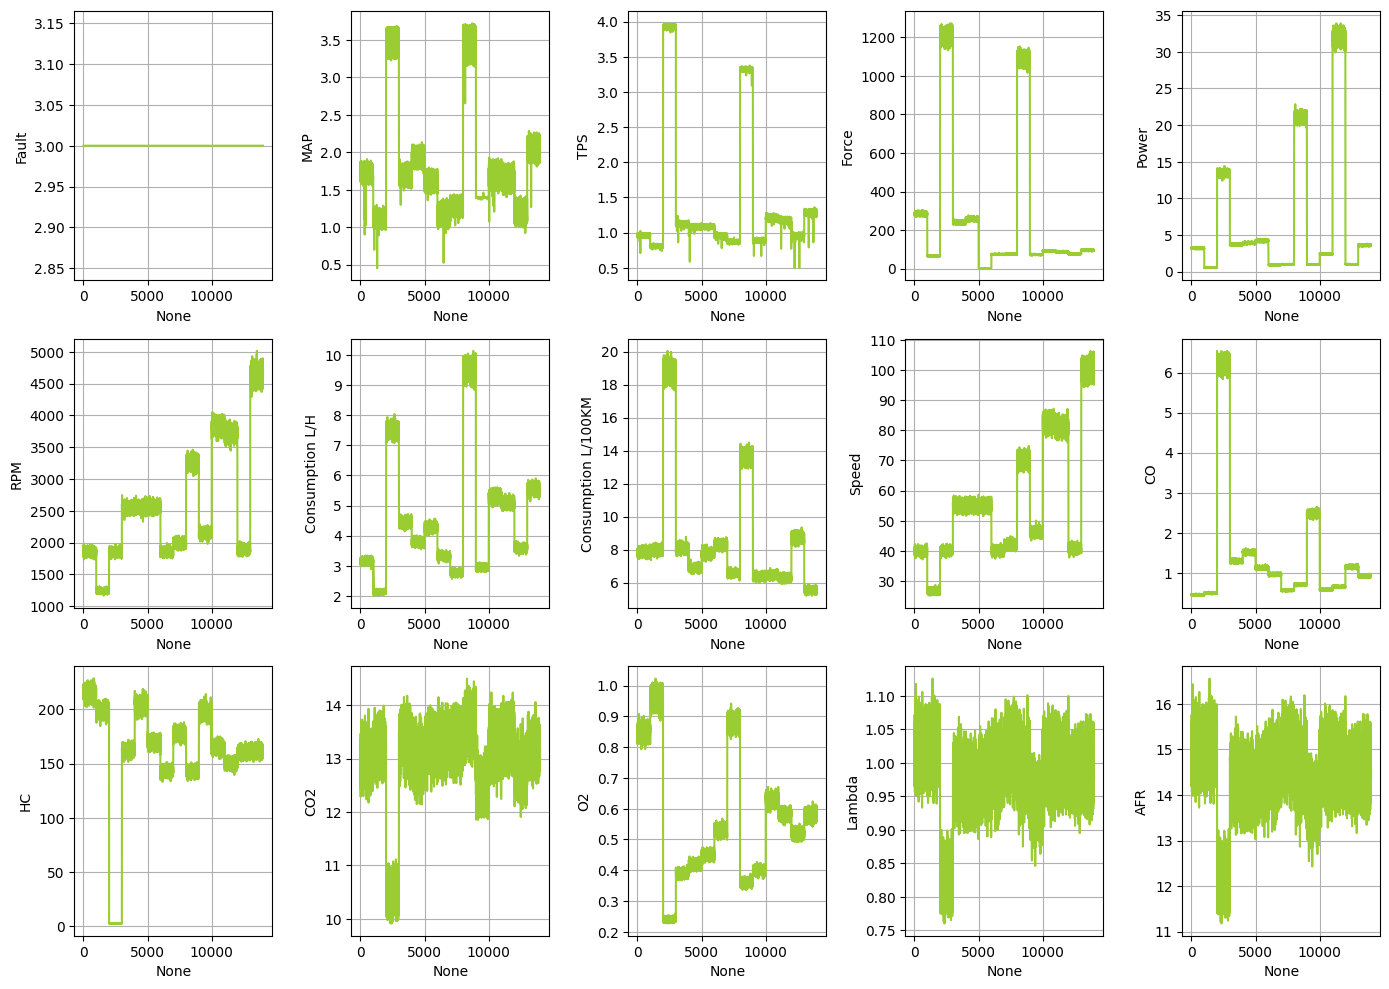

In [15]:
c_3 = d_3.columns

plt.figure(figsize=(14,10))
for i,col in enumerate(c_3):
  plt.subplot(3,5,i+1)
  sns.lineplot(x=d_3.index,y=col,data=d_3,color='yellowgreen')
  plt.grid()

plt.tight_layout()
plt.show()

<Figure size 1400x1000 with 0 Axes>

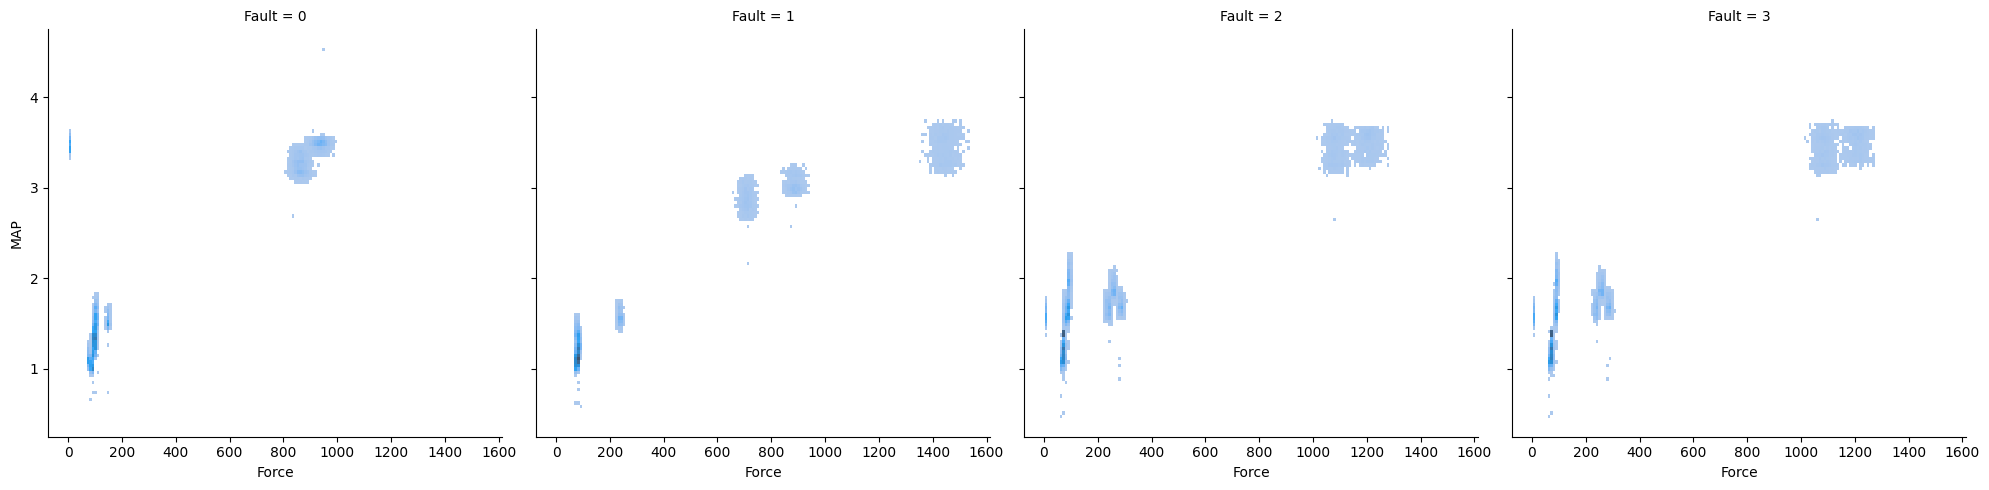

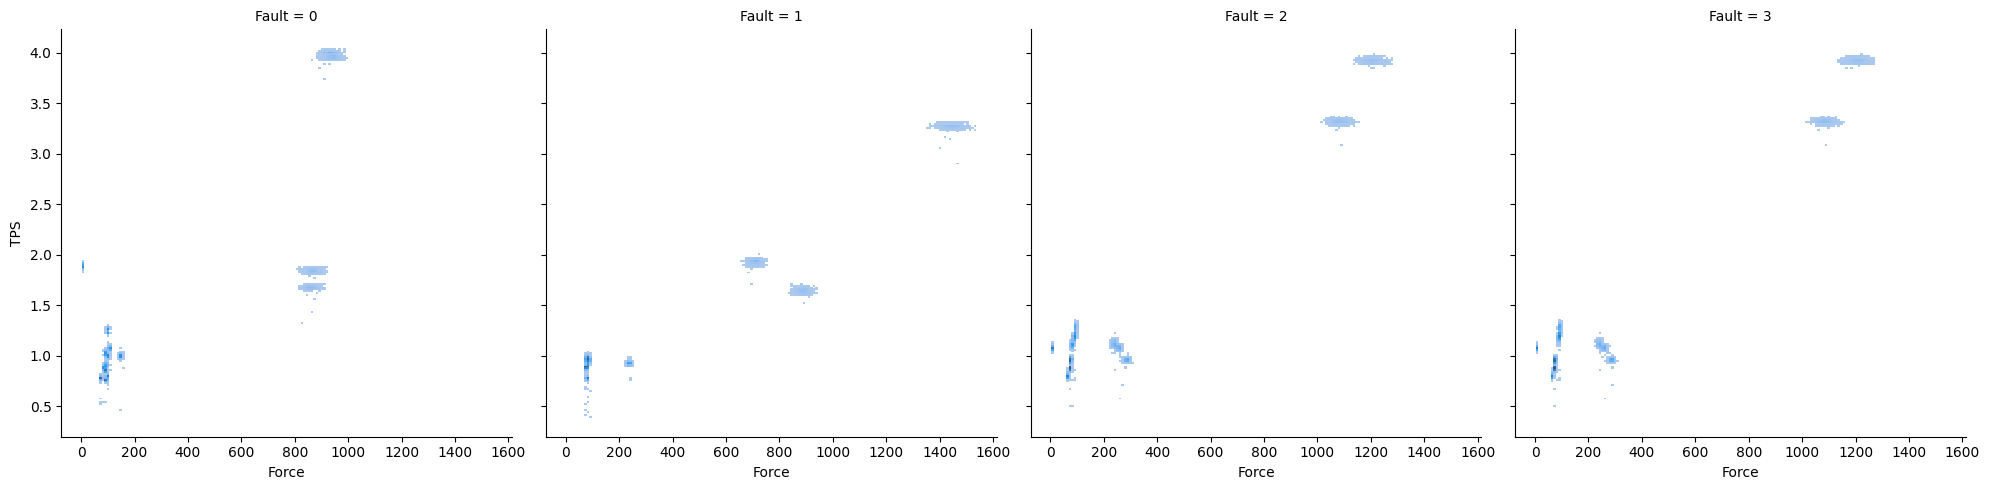

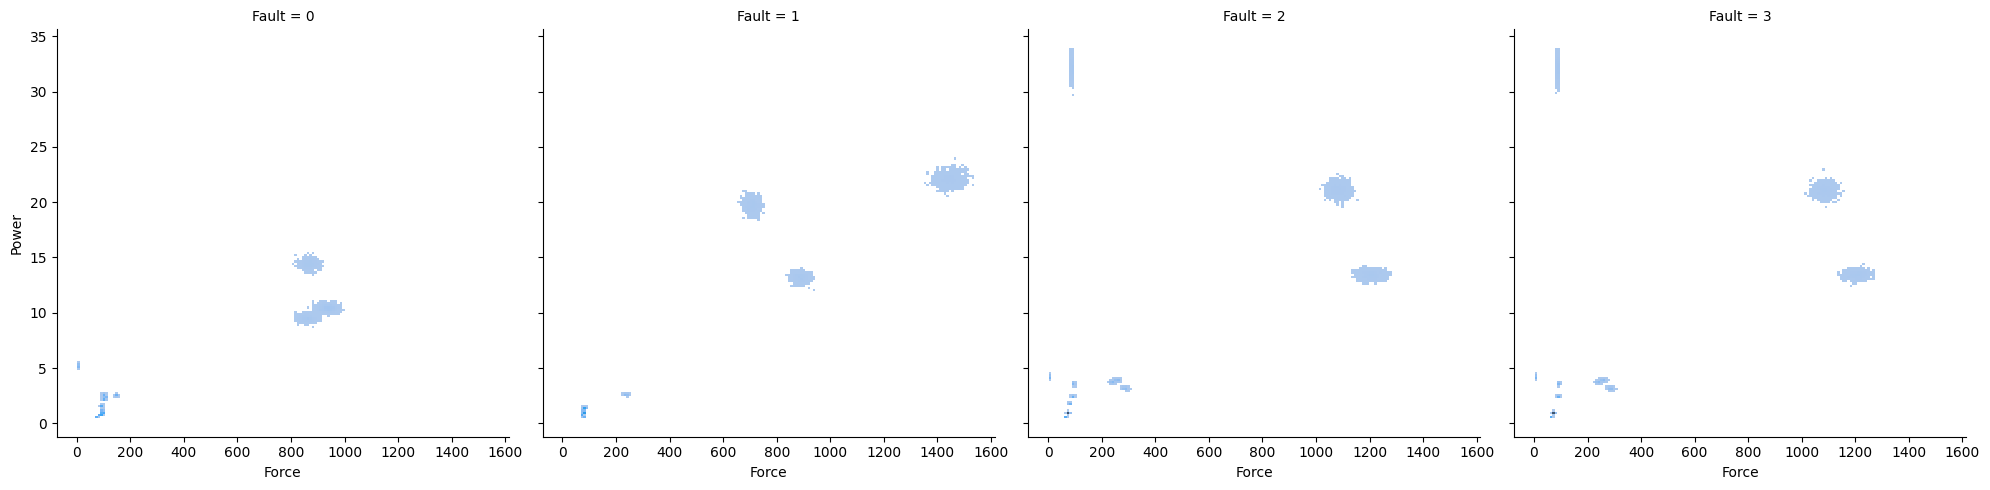

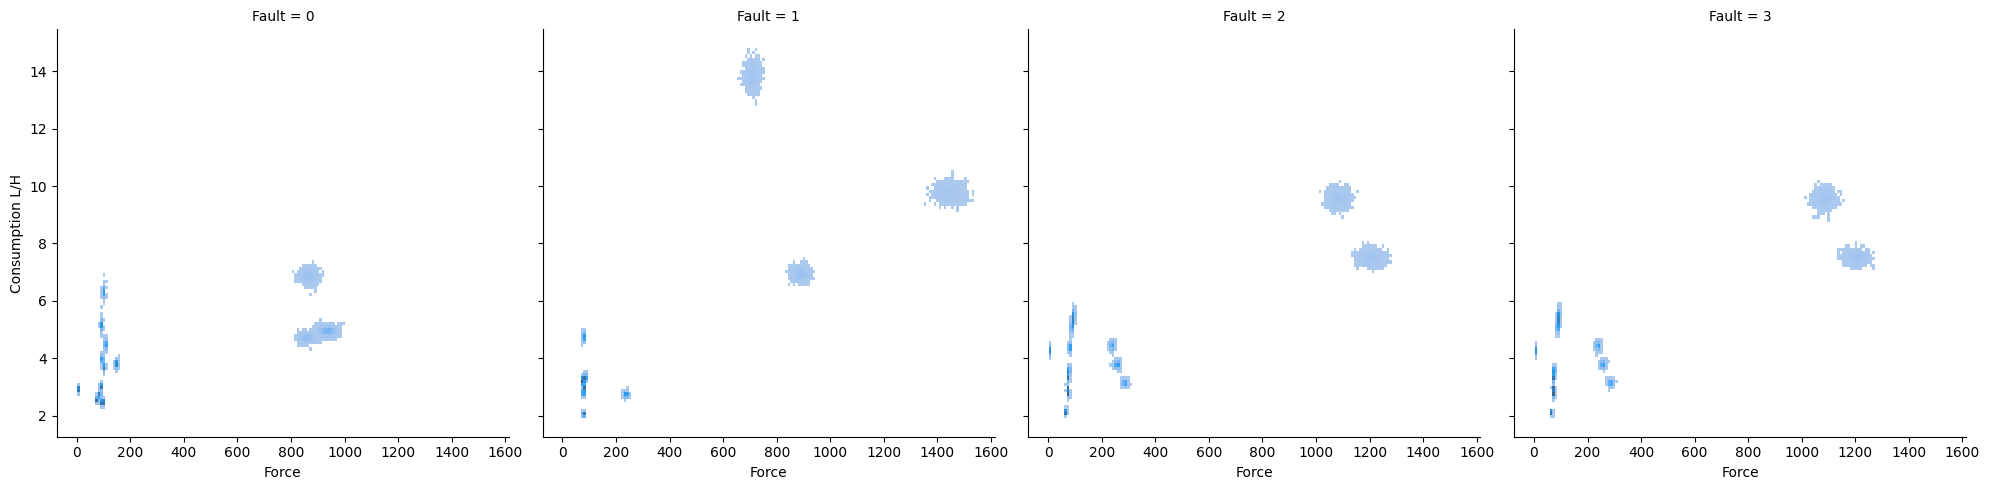

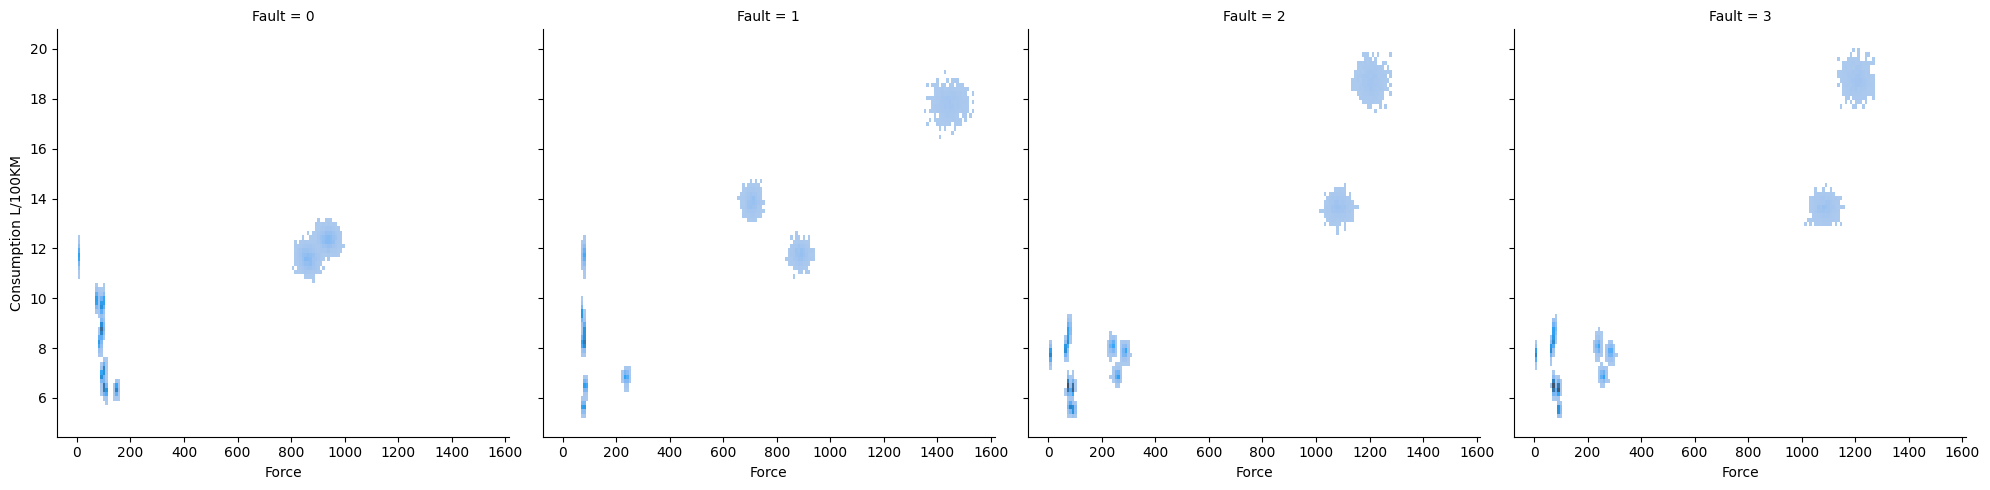

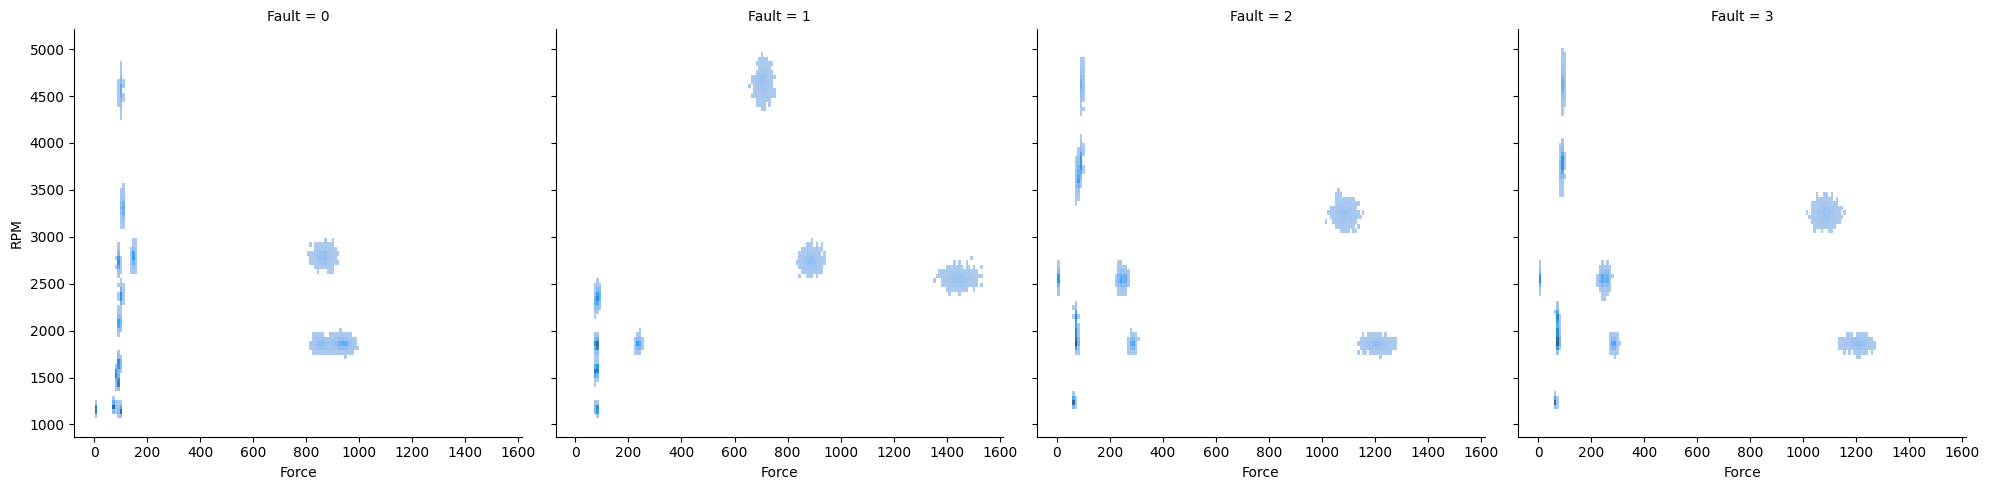

In [16]:
c_dis = d[['MAP','TPS','Power','Consumption L/H','Consumption L/100KM', 'RPM']].columns

plt.figure(figsize=(14,10))
for i,col in enumerate(c_dis):
  sns.displot(
    data=d, x="Force", y=col, col="Fault",
    )

plt.tight_layout()

Force와 MAP, TPS, Consumption L/100KM가 양의 선형관계 > Force만 분석하면 OK

Text(0.5, 1.0, 'Pearson Correlation about Force')

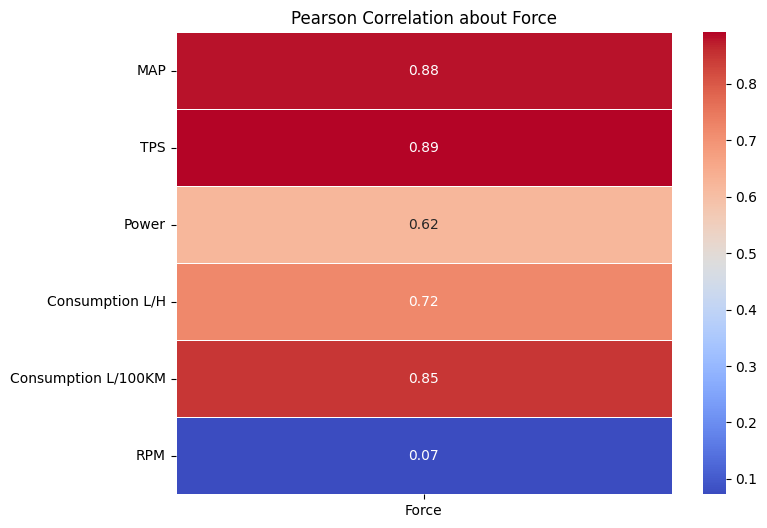

In [17]:
# 위 displot을 상관계수 heatmap을 통해 직관적인 자료로 변경
corr_matrix = d[['Force'] + list(c_dis)].corr(method='pearson')
corr_with_force = corr_matrix[['Force']].drop('Force')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_with_force, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation about Force")

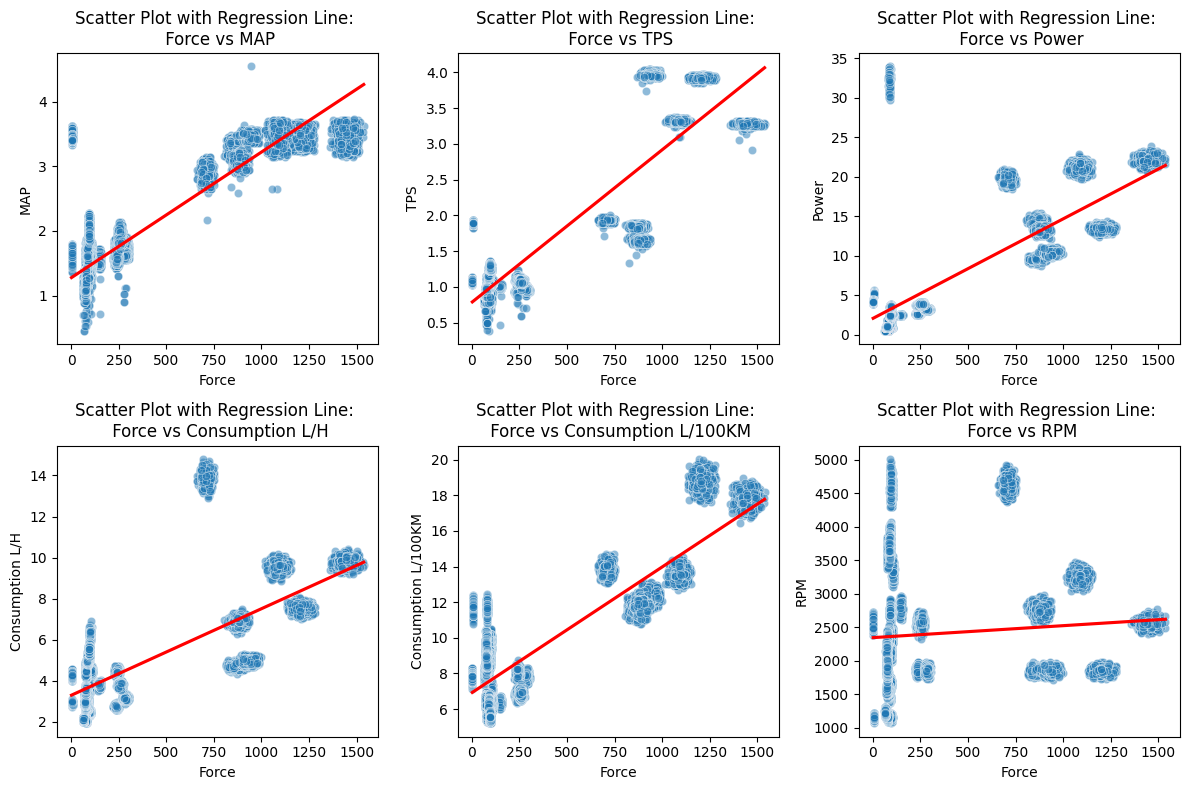

In [18]:
# 자료 추가
c_dis = d[['MAP','TPS','Power','Consumption L/H','Consumption L/100KM', 'RPM']].columns
plt.figure(figsize=(12, 8))
for i, col in enumerate(c_dis):
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(data=d, x="Force", y=col, alpha=0.5) 
    sns.regplot(data=d, x="Force", y=col, scatter=False, color='red')
    plt.title(f'Scatter Plot with Regression Line: \n Force vs {col}')
    plt.xlabel('Force')
    plt.ylabel(col)
plt.tight_layout()

<Figure size 1400x1000 with 0 Axes>

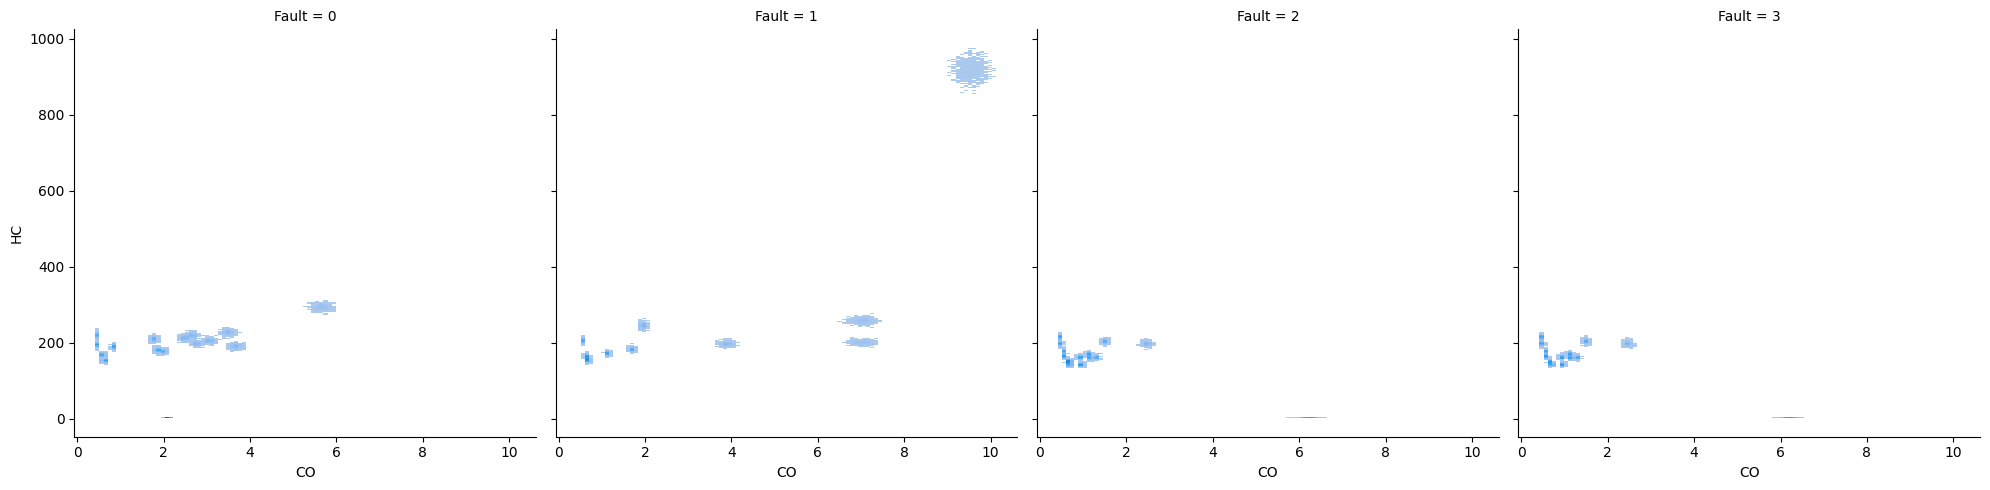

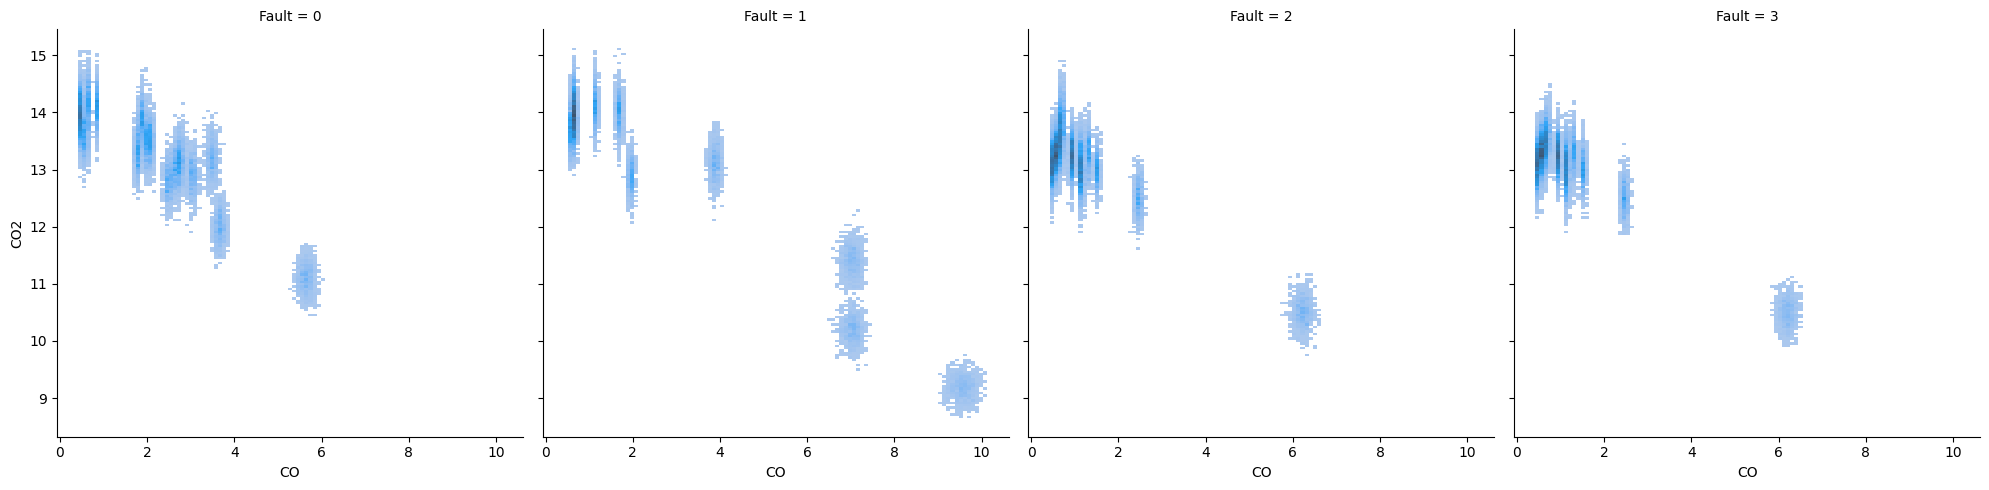

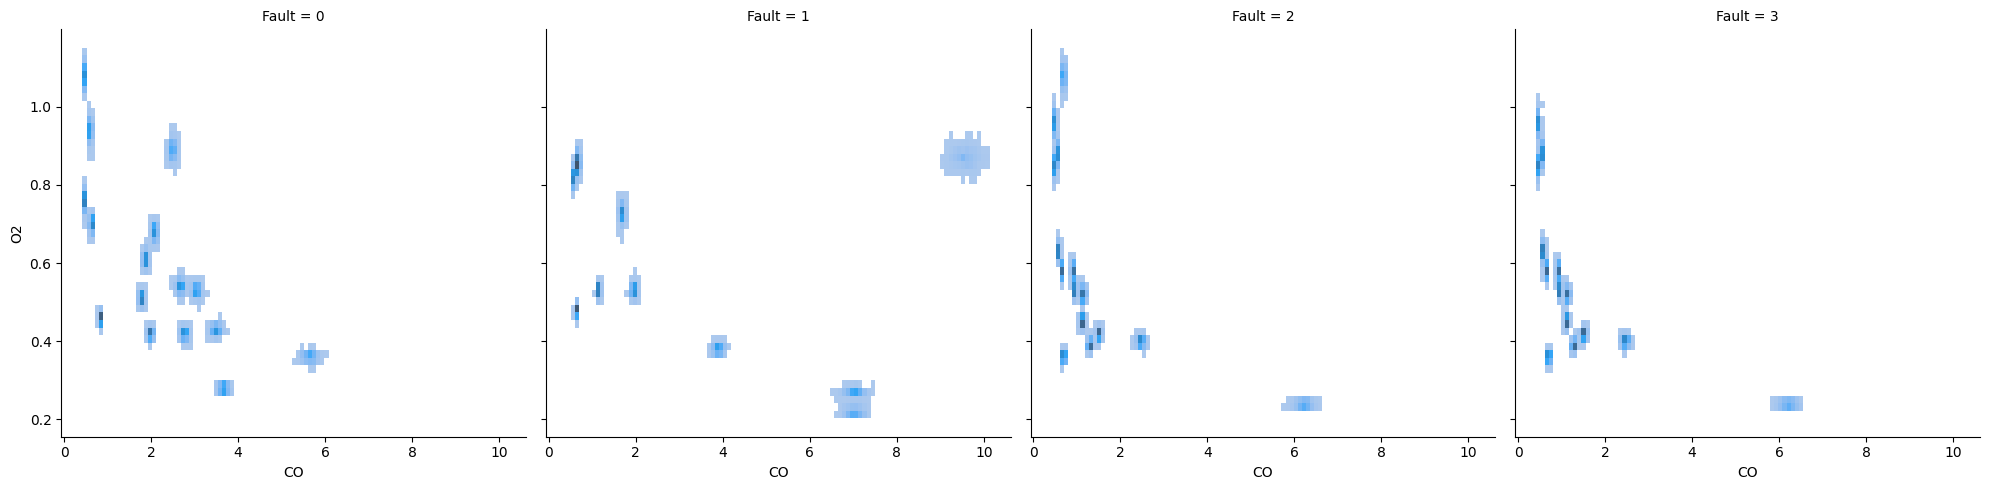

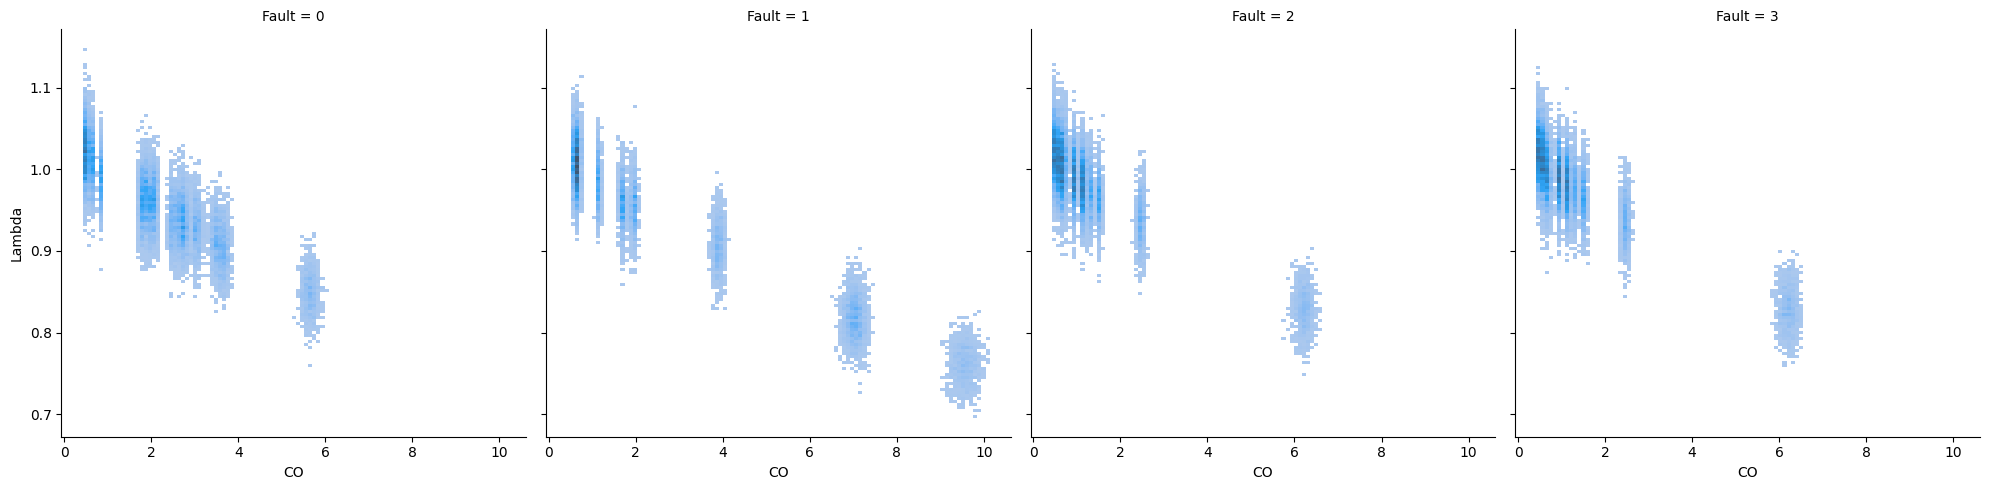

In [19]:
c_dis1 = d[['HC','CO2','O2','Lambda']].columns

plt.figure(figsize=(14,10))
for i,col in enumerate(c_dis1):
  sns.displot(
    data=d, x="CO", y=col, col="Fault",
    )

plt.tight_layout()

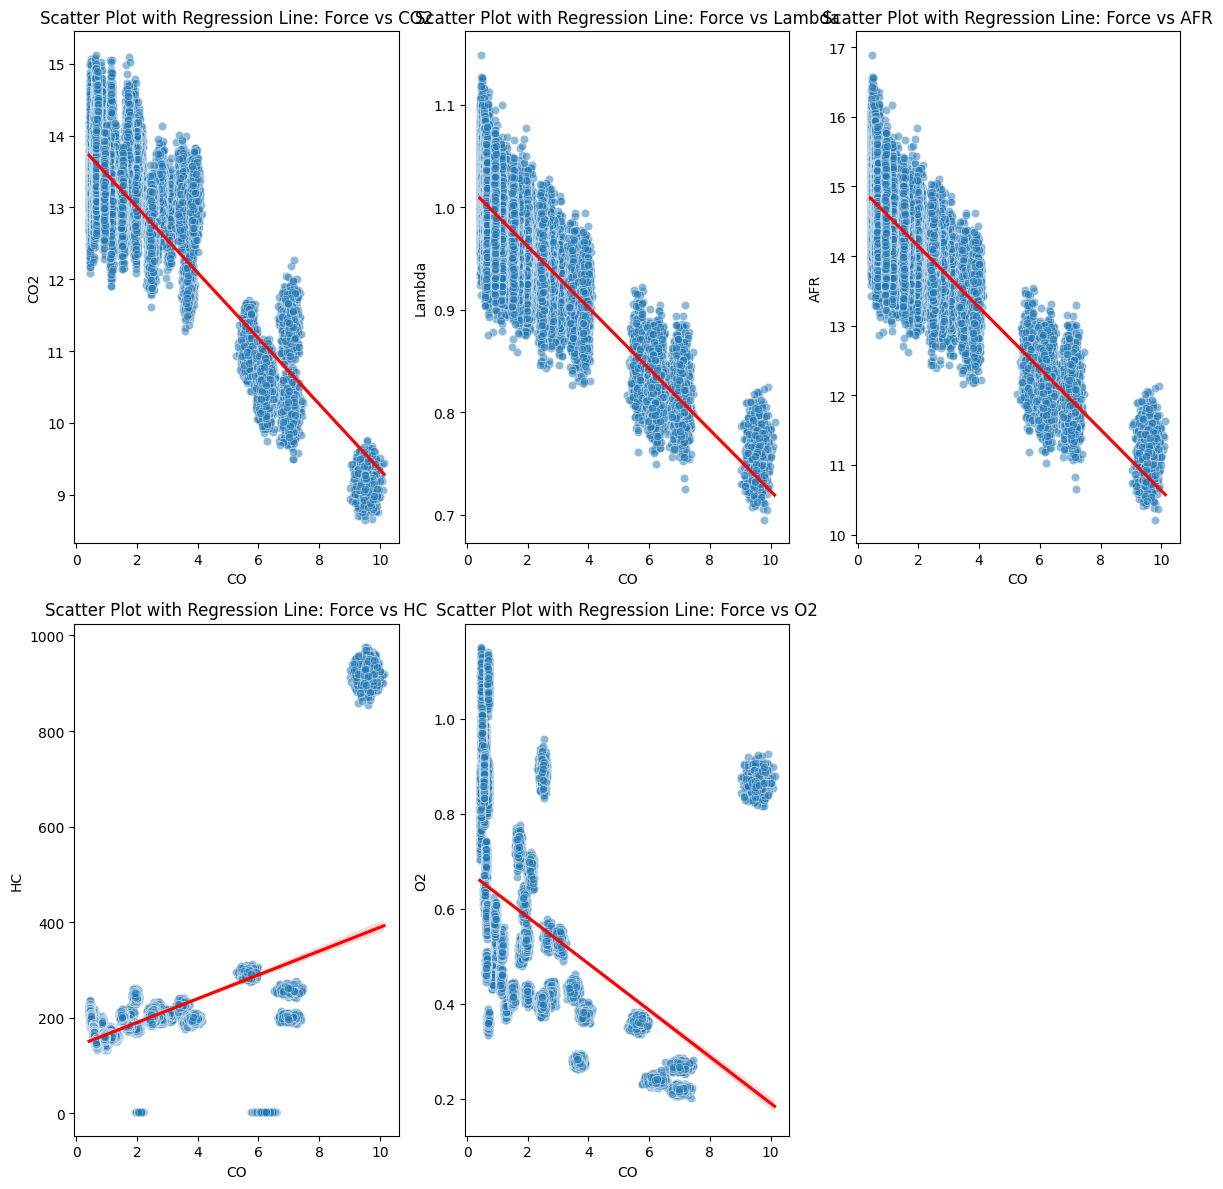

In [20]:
c_dis1=d[['CO2', 'Lambda', 'AFR', 'HC', 'O2']].columns

plt.figure(figsize=(12, 12))
for i, col in enumerate(c_dis1):
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(data=d, x="CO", y=col, alpha=0.5) 
    sns.regplot(data=d, x="CO", y=col, scatter=False, color='red')
    plt.title(f'Scatter Plot with Regression Line: Force vs {col}')
    plt.xlabel('CO')
    
    plt.ylabel(col)

plt.tight_layout()

CO와 CO2, Lambda(AFR)이 음의 선형관계 > CO만 분석하면 OK

**결론: 'Force', 'Power', 'RPM', 'Consumption L/H', 'CO', 'HC', 'O2' 총 7개의 데이터를 선정**

In [21]:
# 모든 Fault에 대해 검정
from scipy.stats import kruskal

variables = ['Force', 'Power', 'RPM', 'Consumption L/H', 'CO', 'HC', 'O2']

groups = {fault: d[d['Fault'] == fault] for fault in [0, 1, 2, 3]}

for var in variables:
    data_0 = groups[0][var]
    data_1 = groups[1][var]
    data_2 = groups[2][var]
    data_3 = groups[3][var]

    stat, p_value = kruskal(data_0, data_1, data_2, data_3)
    print(f"{var}:")
    print(f" H 통계량: {stat}, p-value: {p_value}")
    
    if p_value < 0.05:
        print("  => 그룹 간 유의미한 차이가 있음.")
    else:
        print("  => 그룹 간 유의미한 차이가 없음.")

Force:
 H 통계량: 2104.4156510861226, p-value: 0.0
  => 그룹 간 유의미한 차이가 있음.
Power:
 H 통계량: 986.353127854504, p-value: 1.6426142743553817e-213
  => 그룹 간 유의미한 차이가 있음.
RPM:
 H 통계량: 4077.194454365981, p-value: 0.0
  => 그룹 간 유의미한 차이가 있음.
Consumption L/H:
 H 통계량: 656.081218508145, p-value: 6.996049449719618e-142
  => 그룹 간 유의미한 차이가 있음.
CO:
 H 통계량: 5994.932887395528, p-value: 0.0
  => 그룹 간 유의미한 차이가 있음.
HC:
 H 통계량: 10028.097451360529, p-value: 0.0
  => 그룹 간 유의미한 차이가 있음.
O2:
 H 통계량: 288.20347288631217, p-value: 3.553856055429413e-62
  => 그룹 간 유의미한 차이가 있음.


결론: 각 Fault 별로 데이터들 간에 영향을 미침 > RF, XGB, LBGM, GB 총 4개의 모델을 돌려봄

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

features = ['Force', 'Power', 'RPM', 'Consumption L/H', 'CO', 'HC', 'O2']
X = d[features]
y = d['Fault']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=20, min_samples_split=5, min_samples_leaf=5, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} 정확도: {acc}")
    print(classification_report(y_test, y_pred))



RandomForest 정확도: 0.7444047619047619
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4847
           1       1.00      1.00      1.00      3261
           2       0.52      0.52      0.52      4481
           3       0.49      0.49      0.49      4211

    accuracy                           0.74     16800
   macro avg       0.75      0.75      0.75     16800
weighted avg       0.74      0.74      0.74     16800


XGBoost 정확도: 0.7473809523809524
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4847
           1       1.00      1.00      1.00      3261
           2       0.52      0.58      0.55      4481
           3       0.50      0.44      0.47      4211

    accuracy                           0.75     16800
   macro avg       0.75      0.75      0.75     16800
weighted avg       0.75      0.75      0.75     16800

[LightGBM] [Warning] Found whitespace in feature_names, rep

XGB가 가장 정확도가 높았음 > 하이퍼파리미터 튜닝을 통해 정확도 향상

In [23]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
# 최적의 하이퍼파라미터
#params = {
#   'n_estimators': 100,
#    'max_depth': 10,
#    'learning_rate': 0.2,
#    'subsample': 0.6,
#    'min_child_weight': 1,
#    'colsample_bytree': 0.7,
#    'gamma': 0.1,
#    'reg_alpha': 0,
#    'reg_lambda': 2
#}
#features = ['Force', 'Power', 'RPM', 'Consumption L/H', 'CO', 'HC', 'O2']
#X = d[features]
#y = d['Fault'] 
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# XGBoost 모델 생성
#model = xgb.XGBClassifier(**params)
# 모델 학습
#model.fit(X_train, y_train)
# 예측
#y_pred = model.predict(X_test)
# 정확도 및 보고서 출력
#acc = accuracy_score(y_test, y_pred)
#print(f"\nXGBoost 정확도: {acc}")
#print(classification_report(y_test, y_pred))

최적 조건: 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.2, 'subsample': 0.6,
    'min_child_weight': 1, 'colsample_bytree': 0.7, 'gamma': 0.1, 'reg_alpha': 0, 'reg_lambda': 2

모델 정확도: 0.7502380952380953
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4847
           1       1.00      1.00      1.00      3261
           2       0.53      0.54      0.54      4481
           3       0.50      0.49      0.50      4211

    accuracy                           0.75     16800
   macro avg       0.76      0.76      0.76     16800
weighted avg       0.75      0.75      0.75     16800



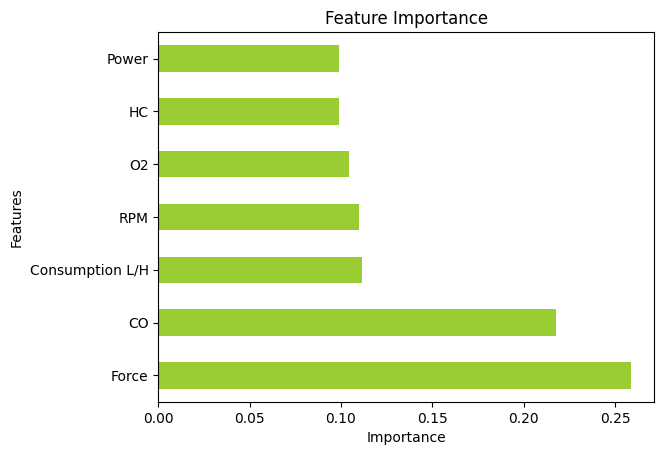

In [24]:
# 최적의 조건으로 다시 XGB 재학습
features = ['Force', 'Power', 'RPM', 'Consumption L/H', 'CO', 'HC', 'O2']
X = d[features]
y = d[['Fault']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

params = {
    'n_estimators': 100,
    'max_depth': 10,
    'learning_rate': 0.2,
    'subsample': 0.6,
    'min_child_weight': 1,
    'colsample_bytree': 0.7,
    'gamma': 0.1,
    'reg_alpha': 0,
    'reg_lambda': 2,
}

model = xgb.XGBClassifier(**params)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"모델 정확도: {acc}")
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh', color='yellowgreen')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

결과: 최초 74.7%에서 튜닝 후, 약 75%까지 정확도 향상
- 이유: Fault 2, 3을 구분하지 못함. 위에 표를 봐도 0, 1은 100% 구분하지만, 2, 3은 각각 51% 밖에 판정하지 못함. 따라서 정확도가 약 75% 정도로 측정됨

Fault 0, 1이 100% 구분되는 이유

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:44:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\User\AppData\Local\Temp\ipykernel_20316\616140215.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


Text(0.5, 1.0, 'Feature Importance (Fault 0 vs Fault 1)')

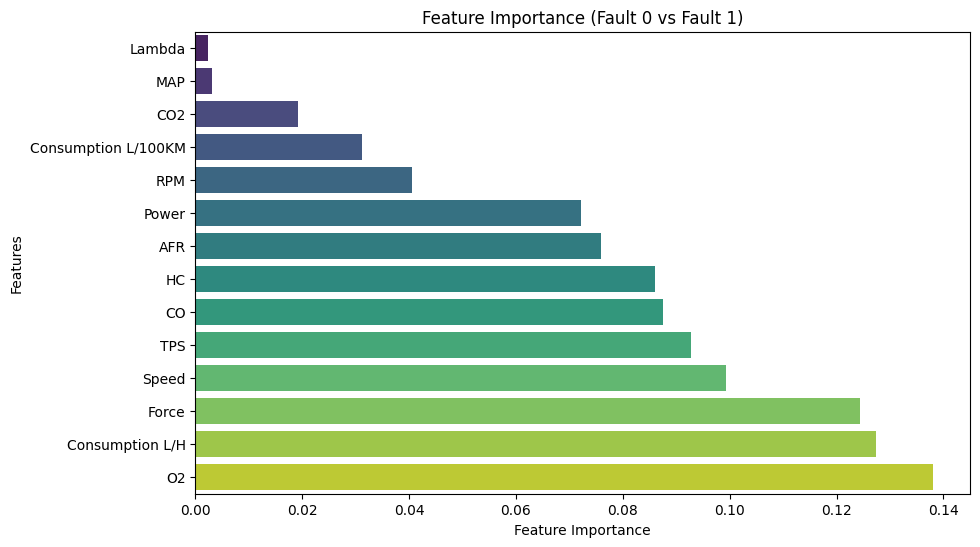

In [25]:
d_01 = d[d['Fault'].isin([0, 1])]

X = d_01.drop(columns=['Fault'])
y = d_01['Fault']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = xgb.XGBClassifier(n_estimators=100, max_depth=10, learning_rate=0.2, subsample=0.6,
                          min_child_weight=1, colsample_bytree=0.7, gamma=0.1,
                          reg_alpha=0, reg_lambda=2, use_label_encoder=False, eval_metric='logloss')

model.fit(X_train, y_train)

feature_importances = model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance (Fault 0 vs Fault 1)')

그럼 이제 왜 Fault 2, 3을 구분하지 못하는 지 증명해보자

1. 분포로 비교하기

KDE로 확인해보니, Fault 2, 3의 데이터 분포가 거의 동일함

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:44:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Text(0.5, 1.0, 'Feature Importance for Fault 2 vs Fault 3')

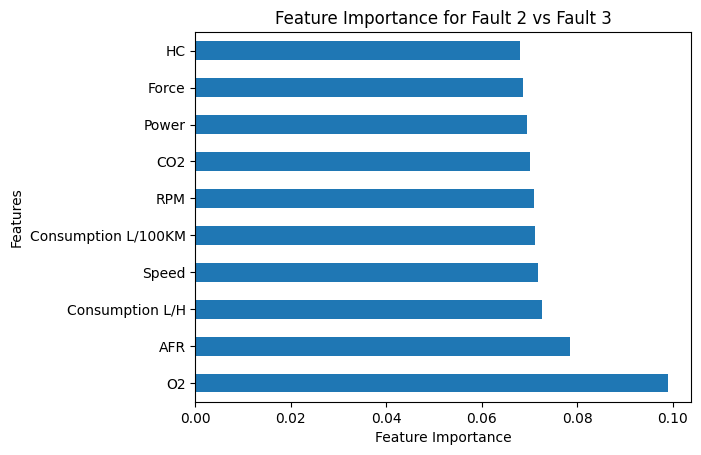

In [26]:
# Fault 2, 3을 구분할 수 있는 Feature Importance
d_23 = d[d['Fault'].isin([2, 3])]

X = d_23.drop(columns=['Fault'])
y = d_23['Fault'].replace({2: 0, 3: 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model_23 = xgb.XGBClassifier(
    n_estimators=100, max_depth=10, learning_rate=0.2, subsample=0.6,
    min_child_weight=1, colsample_bytree=0.7, gamma=0.1,
    reg_alpha=0, reg_lambda=2, use_label_encoder=False, eval_metric='logloss'
)

model_23.fit(X_train, y_train)
importances = model_23.feature_importances_

feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance for Fault 2 vs Fault 3")

C:\Users\User\AppData\Local\Temp\ipykernel_20316\943177131.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(d[d['Fault'] == 2][feature], ax=axes[row, col], label="Fault 2", shade=True)
C:\Users\User\AppData\Local\Temp\ipykernel_20316\943177131.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(d[d['Fault'] == 3][feature], ax=axes[row, col], label="Fault 3", shade=True)
C:\Users\User\AppData\Local\Temp\ipykernel_20316\943177131.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(d[d['Fault'] == 2][feature], ax=axes[row, col], label="Fault 2", shade=True)
C:\Users\User\AppData\Local\Temp\ipykernel_20316\943177131.py:8:

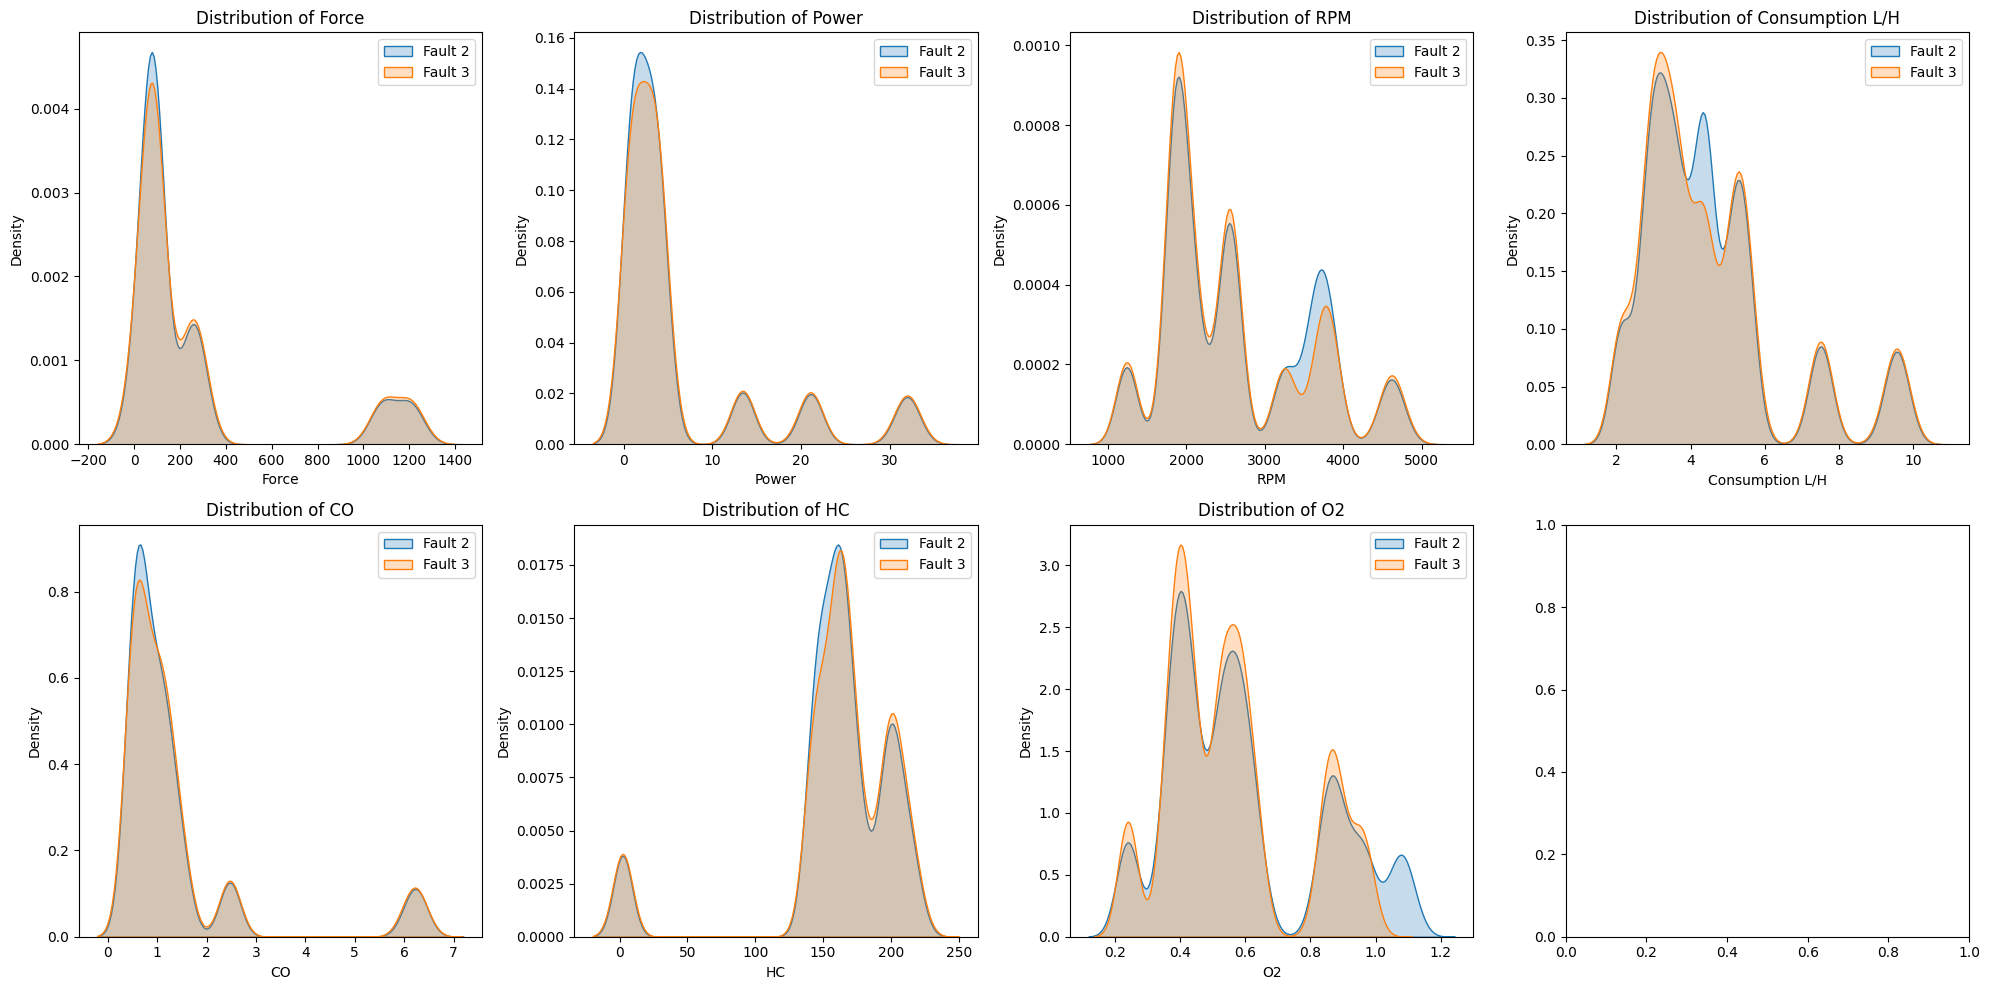

In [27]:
# Fault 2, 3의 데이터 분포 비교 
features = ['Force', 'Power', 'RPM', 'Consumption L/H', 'CO', 'HC', 'O2']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  

for i, feature in enumerate(features):
    row, col = divmod(i, 4)
    sns.kdeplot(d[d['Fault'] == 2][feature], ax=axes[row, col], label="Fault 2", shade=True)
    sns.kdeplot(d[d['Fault'] == 3][feature], ax=axes[row, col], label="Fault 3", shade=True)
    axes[row, col].set_title(f"Distribution of {feature}")
    axes[row, col].legend()
plt.tight_layout()

중요도가 가장 높은 Consumption L/H의 분포가 거의 동일 > Fault 2, 3을 구분하기는 어려움

2. 검정을 통해 증명

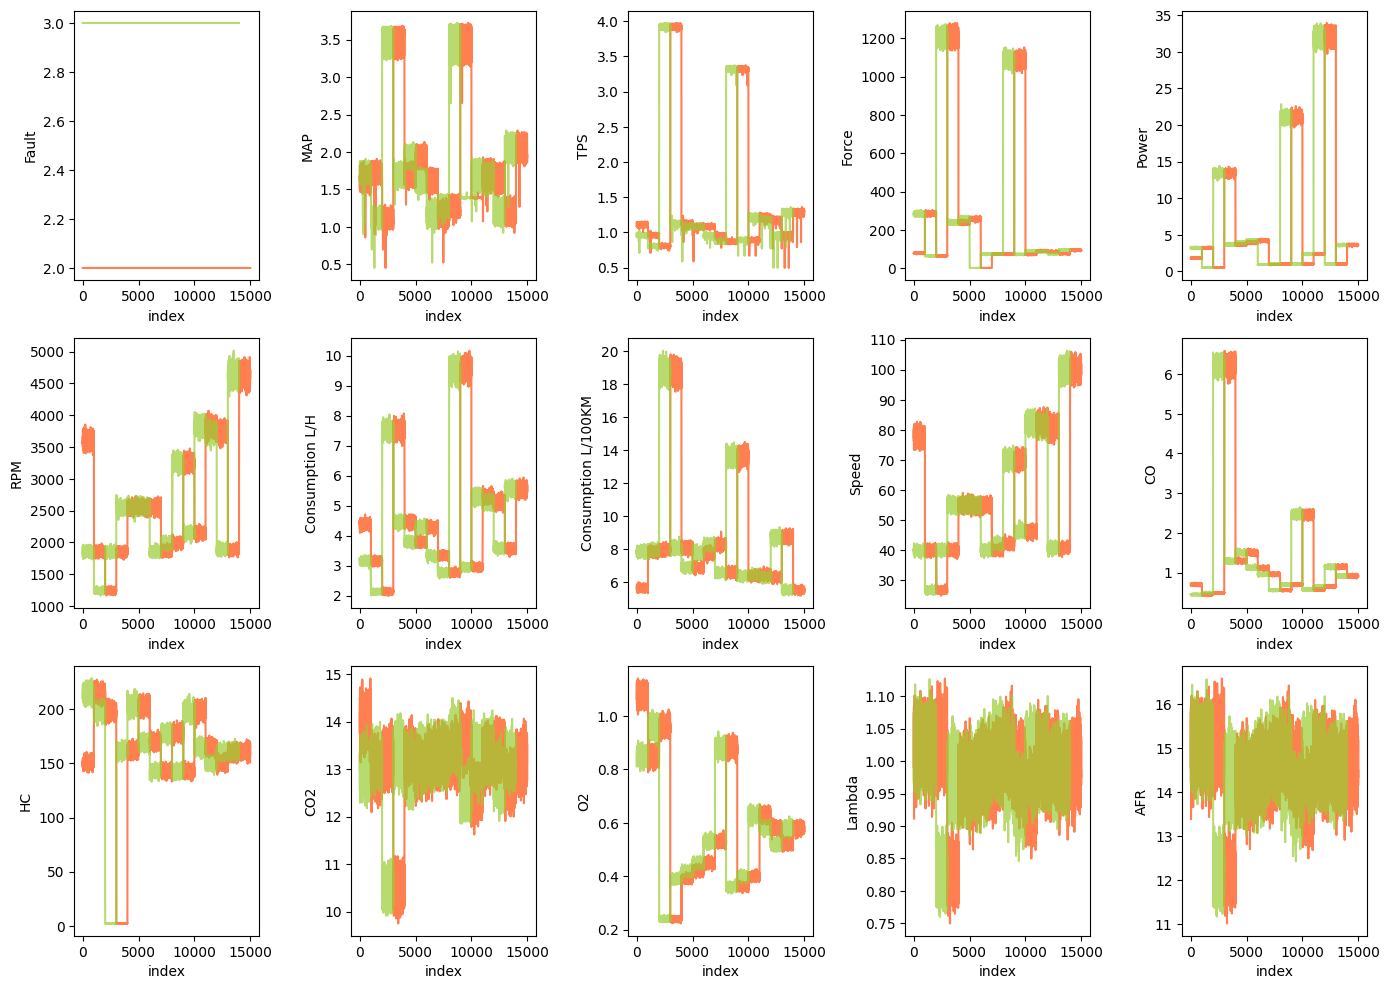

In [28]:
plt.figure(figsize=(14,10))
for i,col in enumerate(c_2):
  plt.subplot(3,5,i+1)
  plt.xlabel('index')
  sns.lineplot(x=d_2.index,y=col,data=d_2,color='coral')

for i,col in enumerate(c_3):
  plt.subplot(3,5,i+1)
  sns.lineplot(x=d_3.index,y=col,data=d_3,color='yellowgreen',alpha=0.7)

plt.tight_layout()
plt.show()

In [29]:
d_3.index = range(1000, 1000 + len(d_3))

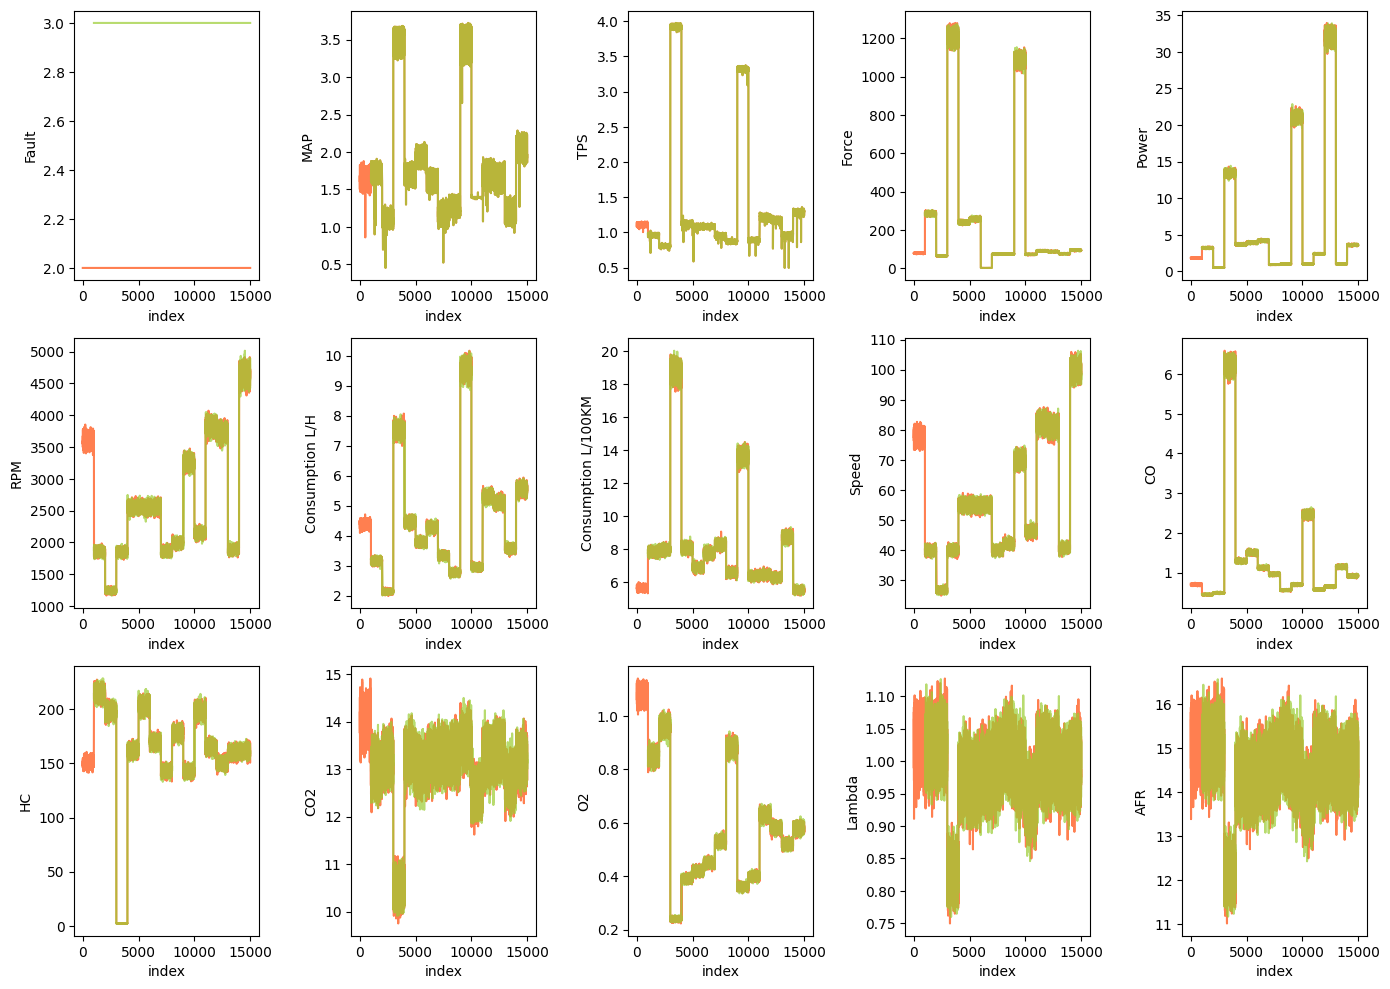

In [30]:
plt.figure(figsize=(14,10))
for i,col in enumerate(c_2):
  plt.subplot(3,5,i+1)
  plt.xlabel('index')
  sns.lineplot(x=d_2.index,y=col,data=d_2,color='coral')

for i,col in enumerate(c_3):
  plt.subplot(3,5,i+1)
  sns.lineplot(x=d_3.index,y=col,data=d_3,color='yellowgreen',alpha=0.7)

plt.tight_layout()
plt.show()

In [31]:
print(d_2.shape[0])
print(d_3.shape[0])

15000
14000


In [32]:
d_2.reset_index(inplace=True)
d_2 = d_2.drop(columns='index', index=range(1000))

d_2와 d_3의 개수를 14000으로 맞춤

In [33]:
from scipy.stats import mannwhitneyu
c = d.columns

for i in c :
  u_stat, mp_value = mannwhitneyu(d_2[i], d_3[i], alternative='two-sided')
  if mp_value >= 0.05:
    print(f"{i}는 귀무가설을 기각할 수 없습니다. 두 집단의 중앙값이 유의미하게 다르지 않습니다.\n--------------------------")

MAP는 귀무가설을 기각할 수 없습니다. 두 집단의 중앙값이 유의미하게 다르지 않습니다.
--------------------------
TPS는 귀무가설을 기각할 수 없습니다. 두 집단의 중앙값이 유의미하게 다르지 않습니다.
--------------------------
Force는 귀무가설을 기각할 수 없습니다. 두 집단의 중앙값이 유의미하게 다르지 않습니다.
--------------------------
Power는 귀무가설을 기각할 수 없습니다. 두 집단의 중앙값이 유의미하게 다르지 않습니다.
--------------------------
RPM는 귀무가설을 기각할 수 없습니다. 두 집단의 중앙값이 유의미하게 다르지 않습니다.
--------------------------
Consumption L/H는 귀무가설을 기각할 수 없습니다. 두 집단의 중앙값이 유의미하게 다르지 않습니다.
--------------------------
Consumption L/100KM는 귀무가설을 기각할 수 없습니다. 두 집단의 중앙값이 유의미하게 다르지 않습니다.
--------------------------
Speed는 귀무가설을 기각할 수 없습니다. 두 집단의 중앙값이 유의미하게 다르지 않습니다.
--------------------------
CO는 귀무가설을 기각할 수 없습니다. 두 집단의 중앙값이 유의미하게 다르지 않습니다.
--------------------------
HC는 귀무가설을 기각할 수 없습니다. 두 집단의 중앙값이 유의미하게 다르지 않습니다.
--------------------------
CO2는 귀무가설을 기각할 수 없습니다. 두 집단의 중앙값이 유의미하게 다르지 않습니다.
--------------------------
O2는 귀무가설을 기각할 수 없습니다. 두 집단의 중앙값이 유의미하게 다르지 않습니다.
--------------------------
Lambda는 귀무가설을 기각할 수 없습니다. 두 집단의 중앙값이 유의미하게 다르